In [1]:
%reload_ext autoreload
%autoreload 2
import sys

sys.path.append("../")
from epd_process_funcs import *

from visualisation import *

In [2]:
edp_path = "4) Data/EDP SA 2023 Data"
edp_files = glob(edp_path + "/SA_site_edp_2023_S*.csv")
df = pd.concat(
    [pd.read_csv(i) for i in edp_files if os.path.getsize(i) > 0]
).reset_index(drop=True)
meta_data1 = pd.read_csv(edp_path + "/edp_sites_metadata_sa_postcode.csv")
meta_data2 = pd.read_csv(edp_path + "/edp_sites_metadata59239829.csv")
meta_data2 = meta_data2[meta_data2["state"] == "SA"]
meta_data3 = meta_data2.merge(
    meta_data1[["edp_site_id", "postcode"]], on="edp_site_id", how="left"
)
meta_data3["Srated"] = (
    meta_data3["inverter_ac_rating_kw"] * meta_data3["inverter_count"]
)
meta_data3["Srated"] = meta_data3.apply(
    lambda row: (
        row["inverter_ac_rating_kw"]
        if pd.isna(row["inverter_count"])
        else row["Srated"]
    ),
    axis=1,
)
meta_data2 = (
    meta_data3.groupby(["edp_site_id", "postcode"]).agg({"Srated": "sum"}).reset_index()
)

In [34]:
df5 = process_edp(df, meta_data2, 10.5 * 60)

In [35]:
ii = 11

Volt-watt non-compliance
Time: 2023-01-15 12:05:00+10:30
site_id: S0186, postcode: 5290
saved as:  /home/hossein/CICCADA/tests/Figures/EDP_voltwatt.jpeg


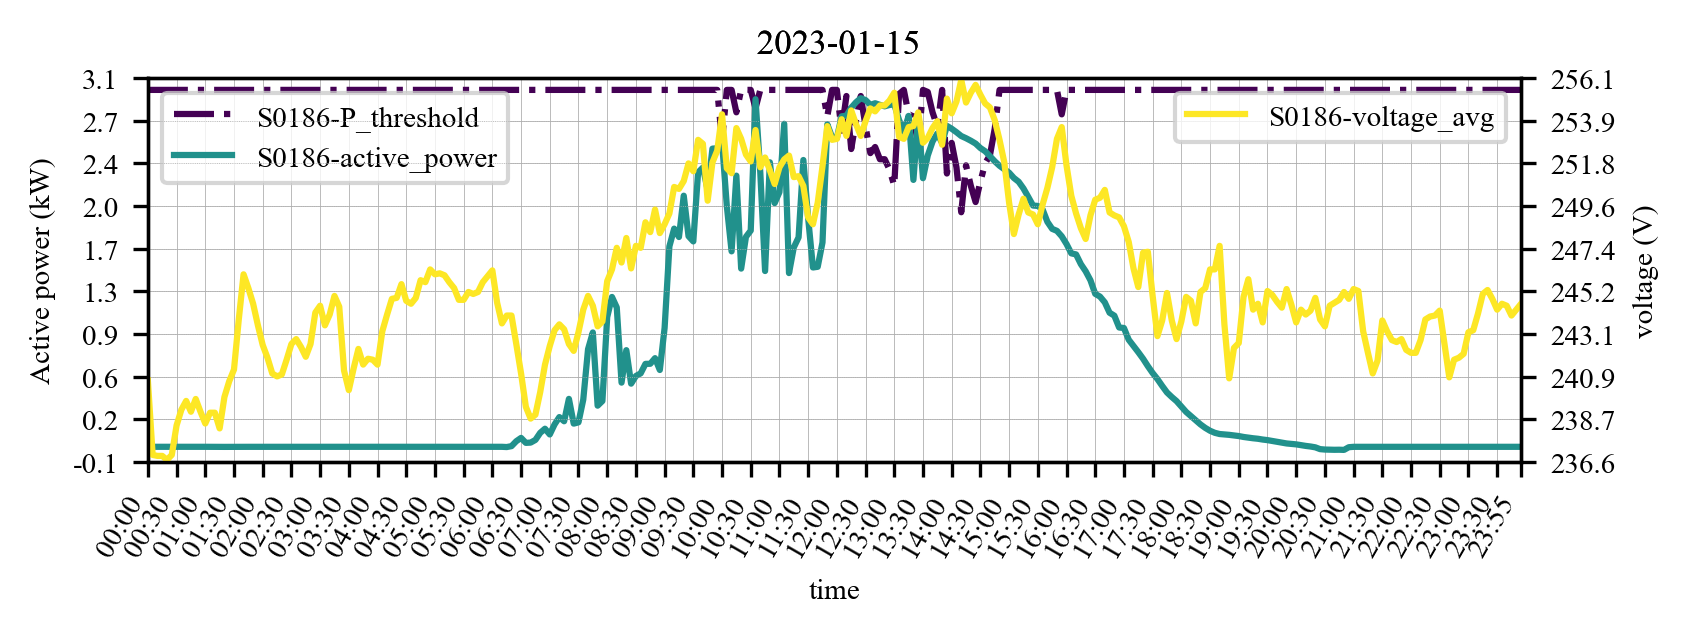

In [51]:
df8 = df5.query(f"P_noncomp > 0 and voltage_avg > 250").reset_index(drop=True)
site_ids = df8["edp_site_id"].unique()[0]
time_t = df8.query(f"edp_site_id == '{site_ids}'")["time"].to_list()[ii]
# ii+=1
t0 = time_t.replace(hour=0, minute=0, second=0, microsecond=0)
t1 = t0 + pd.Timedelta(days=1)
print(f"Volt-watt non-compliance")
print(f"Time: {time_t}")
print(f"site_id: {site_ids}, postcode: {df8['postcode'].unique()[0]}")
df8 = df5.copy()
df8 = df8[df8["edp_site_id"] == site_ids].reset_index(drop=True)
start_time = t0  # In sydney local time
end_time = t1  # In sydney local time


num_ticks = 24 * 2 + 1
save_as = "Figures/EDP_voltwatt.jpeg"
x_label = "time"
y_labels = ["Active power (kW)", "Active power (kW)", "voltage (V)"]
plt_config = {
    "P_threshold": [0, 0, "-.", None, None],
    "active_power": [0, 0, "-", None, None],
    "voltage_avg": [0, 1, "-", None, None],
}

color_nights = False
# color_by = 'group'
color_by = "attribute"
ax_digit = "1.1f"
a = my_plot4(
    start_time,
    end_time,
    df8,
    plt_config=plt_config,
    ax_digit=ax_digit,
    group_attr="edp_site_id",
    time_attr="time",
    color_nights=color_nights,
    cmap="viridis",
    figsize=[14 / 2.54, 2],
    same_scale=1,
    fontsize=7,
    fontname="Times New Roman",
    plot_total=False,
    plot_total_func=["sum", [lambda x: max(x), "max"]],
    num_ticks=num_ticks,
    num_yticks=10,
    dpi=300,
    x_format="%H:%M",
    legend_loc=["upper left", "upper right", "upper right"],
    x_label=x_label,
    y_labels=y_labels,
    color_by=color_by,
    plot_period=np.timedelta64(1, "D"),
    save_as=save_as,
    rotation=60,
    step=0,
    gridwidth=[0.2, 0.2],
    legend_join="-",
    title="",
    legend_i=0,
    title_i=0,
    only1title=0,
)
a.do()

In [50]:
meta_data3.query(f"edp_site_id == 'S0186'")

,first_date_metadata_received,last_date_metadata_received,edp_site_id,state,site_timezone,monitoring_hardware,inverter_manufacturer,inverter_model,inverter_ac_rating_kw,inverter_count,...,subarray_modules_per_string,subarray_dc_rating_kw,islandable,has_battery,battery_size_make_model,limit_enabled,limit_amount,limit_applied,postcode,Srated
43,2022-04-14,2022-06-30,S0186,SA,Australia/Adelaide,SC-23,SolaX Power,SL-TL3300T,3.0,1.0,...,12.0,3.12,No,f,NaN,NaN,NaN,NaN,5290,3.0
